#### Getting the data

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [48]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [49]:
df = df.loc[:, ['engine_displacement',
                 'horsepower',
                 'vehicle_weight',
                 'model_year',
                 'fuel_efficiency_mpg']]

In [50]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


#### Exploratory Data Analysis

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

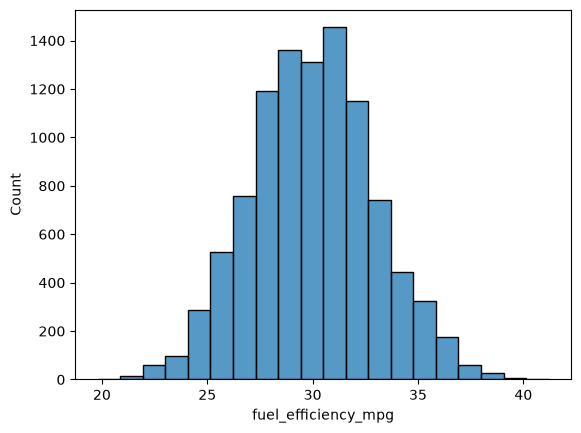

In [51]:
sns.histplot(df.fuel_efficiency_mpg, bins=20)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

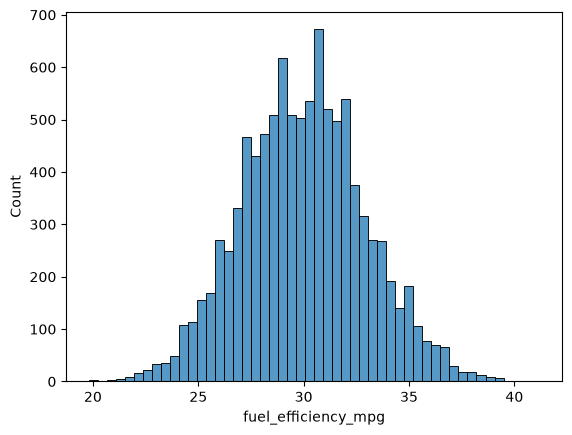

In [52]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


In [54]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


In [55]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

#### Preparing Data

In [56]:
np.random.seed(42)

In [57]:
index = np.arange(len(df))

In [58]:
index[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [59]:
np.random.shuffle(index)

In [60]:
index[:10]

array([6252, 4684, 1731, 4742, 4521, 6340,  576, 5202, 6363,  439])

In [61]:
validation_size = int(len(df) * 0.2)
test_size = int(len(df) * 0.2)
train_size = len(df) - validation_size - test_size

In [62]:
print(train_size)
print(validation_size)
print(test_size)

6000
2000
2000


In [63]:
train_df = df.iloc[index[:train_size]]
validation_df = df.iloc[index[train_size:train_size + validation_size]] 
test_df = df.iloc[index[train_size + validation_size:]]

In [64]:
train_df.reset_index(drop=True, inplace=True)
validation_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [65]:
y_train = train_df.fuel_efficiency_mpg.values
y_validation = validation_df.fuel_efficiency_mpg.values
y_test = test_df.fuel_efficiency_mpg.values

In [66]:
train_df = train_df.drop('fuel_efficiency_mpg', axis=1)
validation_df = validation_df.drop('fuel_efficiency_mpg', axis=1)
test_df = test_df.drop('fuel_efficiency_mpg', axis=1)

#### Training linear regression

In [67]:
def prepare_x(df, null_replacement = 'zero'):
    df = df.copy()
    if null_replacement == 'mean':
        df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())
    if null_replacement == 'zero':
        df['horsepower'] = df['horsepower'].fillna(0)
    X = np.array(df)
    return X

In [68]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

In [69]:
def rmse(y_true, y_pred):
    return np.sqrt(((y_true - y_pred) ** 2).mean())

In [70]:
horsepower_mean = train_df['horsepower'].mean()
for replacement in ['zero', 'mean']:
    train_x = prepare_x(train_df, null_replacement=replacement)
    w0, w = train_linear_regression(train_x, y_train)
    validation_df_imputed = validation_df.copy()
    if replacement == 'mean':
        validation_df_imputed['horsepower'] = validation_df_imputed['horsepower'].fillna(horsepower_mean)
    validation_x = prepare_x(validation_df_imputed, null_replacement='zero')
    y_pred = w0 + validation_x.dot(w)
    rmse_val = rmse(y_validation, y_pred)
    print(f'RMSE for null replacement "{replacement}": {round(rmse_val, 3)}')


RMSE for null replacement "zero": 2.205
RMSE for null replacement "mean": 2.202


#### Train linear regression with regularization

In [71]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

In [72]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    train_x = prepare_x(train_df, null_replacement='zero')
    w0, w = train_linear_regression_reg(train_x, y_train, r)
    validation_x = prepare_x(validation_df, null_replacement='zero')
    y_pred = w0 + validation_x.dot(w)
    rmse_val = rmse(y_validation, y_pred)
    print(f'RMSE for regularization parameter "{r}": {round(rmse_val, 4)}')

RMSE for regularization parameter "0": 2.2053
RMSE for regularization parameter "0.01": 2.2058
RMSE for regularization parameter "0.1": 2.2241
RMSE for regularization parameter "1": 2.3492
RMSE for regularization parameter "5": 2.4094
RMSE for regularization parameter "10": 2.4195
RMSE for regularization parameter "100": 2.4292


#### Different seeds

In [73]:
rmses = []
for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(s)
    index = np.arange(len(df))
    np.random.shuffle(index)
    validation_size = int(len(df) * 0.2)
    test_size = int(len(df) * 0.2)
    train_size = len(df) - validation_size - test_size
    df_shuffled = df.iloc[index]
    split_train_df = df_shuffled.iloc[:train_size].copy()
    split_validation_df = df_shuffled.iloc[train_size:train_size+validation_size].copy()
    split_test_df = df_shuffled.iloc[train_size+validation_size:].copy()
    split_train_df.reset_index(drop=True, inplace=True)
    split_validation_df.reset_index(drop=True, inplace=True)
    split_test_df.reset_index(drop=True, inplace=True)
    split_y_train = split_train_df.fuel_efficiency_mpg.values
    split_y_validation = split_validation_df.fuel_efficiency_mpg.values
    split_train_df = split_train_df.drop('fuel_efficiency_mpg', axis=1)
    split_validation_df = split_validation_df.drop('fuel_efficiency_mpg', axis=1)
    split_train_x = prepare_x(split_train_df, null_replacement='zero')
    split_validation_x = prepare_x(split_validation_df, null_replacement='zero')
    w0, w = train_linear_regression(split_train_x, split_y_train)
    y_pred = w0 + split_validation_x.dot(w)
    rmse_val = rmse(split_y_validation, y_pred)
    rmses.append(rmse_val)
print(round(np.std(rmses), 3))


0.029


#### Combining training and validation datasets

In [74]:
np.random.seed(9)
index = np.arange(len(df))
np.random.shuffle(index)
validation_size = int(len(df) * 0.2)
test_size = int(len(df) * 0.2)
train_size = len(df) - validation_size - test_size
df_shuffled = df.iloc[index]
train_df = df_shuffled.iloc[:train_size].copy()
validation_df = df_shuffled.iloc[train_size:train_size+validation_size].copy()
test_df = df_shuffled.iloc[train_size+validation_size:].copy()
train_df.reset_index(drop=True, inplace=True)
validation_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)
y_train = train_df.fuel_efficiency_mpg.values
y_validation = validation_df.fuel_efficiency_mpg.values
y_test = test_df.fuel_efficiency_mpg.values
train_df = train_df.drop('fuel_efficiency_mpg', axis=1)
validation_df = validation_df.drop('fuel_efficiency_mpg', axis=1)
test_df = test_df.drop('fuel_efficiency_mpg', axis=1)
train_val_df = pd.concat([train_df, validation_df], axis=0)
y_train_val = np.concatenate([y_train, y_validation])
train_x = prepare_x(train_val_df, null_replacement="zero")
w0, w = train_linear_regression_reg(train_x, y_train_val, r = 0.001)
test_x = prepare_x(test_df, null_replacement="zero")
y_pred = w0 + test_x.dot(w)
rmse_test = rmse(y_test, y_pred)

In [75]:
rmse_test

np.float64(2.235827747191731)